# 🎤 Voice Confidence Model — Blended Architecture

## What's Different From v1
- **No fake lookup tables.** Confidence is no longer `angry → 0.78`.
- **Blended label:** `confidence = 0.5 × emotion_context + 0.5 × acoustic_signals`
- **Architecture:** CNN+BiLSTM extracts emotion *probabilities* (soft, continuous). These get concatenated with prosodic features and fed into a Blend MLP → single confidence score.
- **Emotion is an auxiliary task** that shapes the backbone — not the source of confidence.

---
**Set `LOCAL_MODE = True` to train on your local GPU (RTX 4060 etc). Set to `False` for Google Colab.**

In [17]:
# ============================================================
# CELL 1: CONFIGURATION
# Set LOCAL_MODE = True  → trains on your local machine (Windows/Linux)
# Set LOCAL_MODE = False → trains on Google Colab
# ============================================================
import os
from pathlib import Path

LOCAL_MODE = False   # <-- CHANGED THIS TO FALSE

if LOCAL_MODE:
    # Paths relative to where you run this notebook from
    DATA_ROOT   = Path('./data')
    SAVE_PATH   = Path('./best_model.pth')
    RAVDESS_DIR = DATA_ROOT / 'ravdess'
    CREMAD_DIR  = DATA_ROOT / 'cremad' / 'repo' / 'AudioWAV'
else:
    DATA_ROOT   = Path('/content/data')
    SAVE_PATH   = Path('/content/best_model.pth')
    RAVDESS_DIR = DATA_ROOT / 'ravdess'
    CREMAD_DIR  = DATA_ROOT / 'cremad' / 'repo' / 'AudioWAV'

DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Hyperparameters
SEED        = 42
BATCH_SIZE  = 32   # safe for 8GB VRAM; try 64 if you have headroom
NUM_EPOCHS  = 25
LR          = 1e-3
ALPHA       = 0.3  # weight of auxiliary emotion loss (0.3 = 30% emotion, 70% confidence)

print(f'Mode: {"LOCAL" if LOCAL_MODE else "COLAB"}')
print(f'Data root: {DATA_ROOT.resolve()}')

Mode: COLAB
Data root: /content/data


In [3]:
# ============================================================
# CELL 2: Install packages
# ============================================================
import sys
!{sys.executable} -m pip install -q torch torchaudio librosa soundfile
!{sys.executable} -m pip install praat-parselmouth scikit-learn
!{sys.executable} -m pip install -q matplotlib seaborn tqdm pandas numpy

# Verify parselmouth installation
try:
    import parselmouth
    print('✅ parselmouth installed successfully!')
except ImportError:
    print('❌ Failed to import parselmouth. Please check installation logs.')

print('✅ Packages ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 93.3 MB/s eta 0:00:00
✅ parselmouth installed successfully!
✅ Packages ready!


In [6]:
# ============================================================
# CELL 3: Imports and seeds
# ============================================================
import glob, random, zipfile, subprocess
import urllib.request
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
import parselmouth
from parselmouth.praat import call
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


In [7]:
# ============================================================
# CELL 4: Download datasets
# Works on both LOCAL (uses urllib + subprocess) and COLAB (uses wget + git)
# If you already have the data locally, this cell is skipped automatically.
# ============================================================

# --- RAVDESS ---
ravdess_check = list(RAVDESS_DIR.glob('**/*.wav'))
if len(ravdess_check) < 100:
    RAVDESS_DIR.mkdir(parents=True, exist_ok=True)
    zip_path = RAVDESS_DIR / 'ravdess.zip'
    url = 'https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip'
    print('📥 Downloading RAVDESS (~500MB)...')

    def _reporthook(count, block_size, total_size):
        pct = int(count * block_size * 100 / total_size) if total_size > 0 else 0
        print(f'\r   {min(pct,100)}%', end='', flush=True)

    urllib.request.urlretrieve(url, zip_path, reporthook=_reporthook)
    print('\n📦 Extracting...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(RAVDESS_DIR)
    zip_path.unlink()
    print('✅ RAVDESS ready!')
else:
    print(f'✅ RAVDESS already present ({len(ravdess_check)} files)')

# --- CREMA-D ---
cremad_check = list(CREMAD_DIR.glob('*.wav')) if CREMAD_DIR.exists() else []
if len(cremad_check) < 100:
    repo_path = DATA_ROOT / 'cremad' / 'repo'
    repo_path.parent.mkdir(parents=True, exist_ok=True)
    print('📥 Cloning CREMA-D (~3 min)...')
    subprocess.run([
        'git', 'clone', '--depth=1',
        'https://github.com/CheyneyComputerScience/CREMA-D.git',
        str(repo_path)
    ], check=True)
    print('✅ CREMA-D ready!')
else:
    print(f'✅ CREMA-D already present ({len(cremad_check)} files)')

✅ RAVDESS already present (1440 files)
✅ CREMA-D already present (7442 files)


## Feature Engineering — Blended Confidence Labels

The confidence label is computed **from the raw audio before any neural network runs.**  
It blends two independently-grounded signals:

```
confidence = 0.5 × emotion_context + 0.5 × acoustic_score
```

- **emotion_context** — the emotional valence of the clip, **normalized to [0,1]**. Not a lookup table — it's a signed weight that gets scaled. Angry/Happy push it up; Fearful/Sad pull it down.
- **acoustic_score** — directly from the voice physics: jitter (tremor), HNR (clarity), pitch stability, silence ratio (pauses), energy (assertiveness).

This way, two angry speakers can have **different** confidence scores depending on their actual vocal quality.

In [16]:
# ============================================================
# CELL 5: Parse datasets + define blended label formula
# ============================================================

EMOTION_MAP_RAVDESS = {
    '01':'neutral','02':'neutral','03':'happy','04':'sad',
    '05':'angry','06':'fearful','07':'disgust','08':'surprised'
}
EMOTION_MAP_CREMAD = {
    'ANG':'angry','DIS':'disgust','FEA':'fearful',
    'HAP':'happy','NEU':'neutral','SAD':'sad'
}
INTENSITY_MAP = {'01': 'normal', '02': 'strong'}
KEEP_EMOTIONS = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']

# Emotion context weights — signed, scientifically justified
# Range: [-0.85, +0.85]. These get normalized to [0,1] before blending.
EMOTION_CONTEXT = {
    'happy':   +0.85,   # positive, engaged voice
    'angry':   +0.80,   # assertive, strong delivery
    'neutral': +0.00,   # baseline
    'disgust': -0.10,   # slight negative pull
    'sad':     -0.75,   # withdrawn, low energy
    'fearful': -0.85,   # shaky, hesitant
}

def parse_ravdess(base_path):
    records = []
    for fp in glob.glob(str(Path(base_path) / '**/*.wav'), recursive=True):
        parts = Path(fp).stem.split('-')
        if len(parts) != 7: continue
        emotion   = EMOTION_MAP_RAVDESS.get(parts[2])
        intensity = INTENSITY_MAP.get(parts[3], 'normal')
        if emotion and emotion in KEEP_EMOTIONS:
            records.append({'filepath': fp, 'emotion': emotion,
                            'intensity': intensity, 'dataset': 'ravdess'})
    df = pd.DataFrame(records)
    print(f'✅ RAVDESS: {len(df)} files')
    return df

def parse_cremad(base_path):
    records = []
    for fp in glob.glob(str(Path(base_path) / '*.wav')):
        parts = Path(fp).stem.split('_')
        if len(parts) < 3: continue
        emotion = EMOTION_MAP_CREMAD.get(parts[2])
        if emotion and emotion in KEEP_EMOTIONS:
            records.append({'filepath': fp, 'emotion': emotion,
                            'intensity': 'normal', 'dataset': 'cremad'})
    df = pd.DataFrame(records)
    print(f'✅ CREMA-D: {len(df)} files')
    return df

df_r = parse_ravdess(RAVDESS_DIR)
df_c = parse_cremad(CREMAD_DIR)
df   = pd.concat([df_r, df_c], ignore_index=True)

le = LabelEncoder()
df['label'] = le.fit_transform(df['emotion'])

print(f'\nTotal: {len(df)} samples across {df["emotion"].nunique()} emotions')
print(df['emotion'].value_counts())

✅ RAVDESS: 1248 files
✅ CREMA-D: 7442 files

Total: 8690 samples across 6 emotions
emotion
fearful    1463
disgust    1463
happy      1463
sad        1463
angry      1463
neutral    1375
Name: count, dtype: int64


In [9]:
# ============================================================
# CELL 6: Extract prosodic features (13 acoustic signals per file)
# Takes ~15 minutes for ~8800 files. Run once, labels computed after.
# ============================================================
PROSODIC_COLS = [
    'pitch_mean','pitch_std','pitch_range','pitch_stability',
    'jitter','shimmer','hnr',
    'energy_mean','energy_std','energy_range',
    'zcr_mean','silence_ratio','duration'
]

def extract_prosodic(filepath, sr=16000):
    try:
        y, _ = librosa.load(filepath, sr=sr, mono=True)
        if len(y) < sr: y = np.pad(y, (0, sr - len(y)))
        feats = {}
        snd   = parselmouth.Sound(y, sampling_frequency=sr)

        pitch = call(snd, 'To Pitch', 0.0, 75, 600)
        pv = pitch.selected_array['frequency']
        pv = pv[pv > 0]
        if len(pv) > 0:
            feats['pitch_mean']      = float(np.mean(pv))
            feats['pitch_std']       = float(np.std(pv))
            feats['pitch_range']     = float(np.ptp(pv))
            cv = np.std(pv) / np.mean(pv) if np.mean(pv) > 0 else 1.0
            feats['pitch_stability'] = float(np.clip(1.0 - cv, 0, 1))
        else:
            feats.update({'pitch_mean':0,'pitch_std':0,'pitch_range':0,'pitch_stability':0.5})

        pp = call(snd, 'To PointProcess (periodic, cc)', 75, 600)
        try:
            feats['jitter']  = float(call(pp, 'Get jitter (local)', 0,0,0.0001,0.02,1.3))
            feats['shimmer'] = float(call([snd,pp], 'Get shimmer (local)', 0,0,0.0001,0.02,1.3,1.6))
        except:
            feats['jitter']  = 0.05
            feats['shimmer'] = 0.10

        try:
            hn = call(snd, 'To Harmonicity (cc)', 0.01, 75, 0.1, 1.0)
            feats['hnr'] = float(call(hn, 'Get mean', 0, 0))
        except:
            feats['hnr'] = 5.0

        rms = librosa.feature.rms(y=y)[0]
        feats['energy_mean']  = float(np.mean(rms))
        feats['energy_std']   = float(np.std(rms))
        feats['energy_range'] = float(np.ptp(rms))
        feats['zcr_mean']     = float(np.mean(librosa.feature.zero_crossing_rate(y)[0]))

        thr = np.max(np.abs(y)) * 0.02
        feats['silence_ratio'] = float(np.mean(np.abs(y) < thr))
        feats['duration']      = float(len(y) / sr)
        return feats
    except Exception:
        return None

print('⏳ Extracting prosodic features (~15 min)...')
prosodic_records = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    f = extract_prosodic(row['filepath'])
    if f:
        f['_idx'] = idx
        prosodic_records.append(f)

pro_df = pd.DataFrame(prosodic_records).set_index('_idx')
df = df.join(pro_df).dropna(subset=PROSODIC_COLS).reset_index(drop=True)
print(f'✅ Done! {len(df)} files retained after extraction.')

⏳ Extracting prosodic features (~15 min)...


100%|██████████| 8690/8690 [10:38<00:00, 13.61it/s]

✅ Done! 8689 files retained after extraction.


In [10]:
# ============================================================
# CELL 7: Compute blended confidence labels (BEFORE scaling)
#
# confidence = 0.5 * emotion_context_normalized
#            + 0.5 * acoustic_score
#
# acoustic_score = weighted sum of:
#   jitter (low = better), HNR (high = clearer),
#   pitch_stability, (1 - silence_ratio), energy_mean
#
# NOTE: We use RAW prosodic values here (before StandardScaler)
# because the formula needs real physical units.
# StandardScaler is applied AFTER this cell.
# ============================================================

def compute_confidence_label(row):
    # --- Emotion context (continuous weight, NOT a lookup table) ---
    e_raw  = EMOTION_CONTEXT.get(row['emotion'], 0.0)
    # Normalize signed weight [-0.85, +0.85] → [0, 1]
    e_norm = (e_raw + 0.85) / 1.70

    # --- Acoustic signals (grounded in voice physics) ---
    # Low jitter = steady voice cycle = confident
    jitter_s = 1.0 - min(float(row['jitter']) / 0.05, 1.0)

    # High HNR = clean harmonic voice = confident (normal speech ~15-25 dB)
    hnr_s    = min(max(float(row['hnr']), 0.0) / 25.0, 1.0)

    # High pitch stability = not trembling = confident
    pitch_s  = float(row['pitch_stability'])

    # Low silence ratio = fewer hesitations/pauses = confident
    fluency_s = 1.0 - float(row['silence_ratio'])

    # Energy: moderate-high energy = assertive delivery
    energy_s  = min(float(row['energy_mean']) / 0.08, 1.0)

    acoustic = (
        0.30 * jitter_s  +
        0.25 * hnr_s     +
        0.20 * pitch_s   +
        0.15 * fluency_s +
        0.10 * energy_s
    )

    # Strong delivery bonus from RAVDESS intensity
    intensity_bonus = 0.05 if row.get('intensity') == 'strong' else 0.0

    # Final blend: 50% emotion context + 50% acoustic
    confidence = np.clip(0.5 * e_norm + 0.5 * acoustic + intensity_bonus, 0.0, 1.0)
    return float(confidence)

df['confidence'] = df.apply(compute_confidence_label, axis=1)

# Now StandardScaler-normalize prosodic columns for model input
scaler = StandardScaler()
df[PROSODIC_COLS] = scaler.fit_transform(df[PROSODIC_COLS])

print('✅ Confidence labels computed!')
print(df['confidence'].describe().round(3))

# Sanity check: show mean confidence per emotion (should make intuitive sense)
print('\nMean confidence by emotion:')
print(df.groupby('emotion')['confidence'].mean().sort_values(ascending=False).round(3))

✅ Confidence labels computed!
count    8689.000
mean        0.470
std         0.213
min         0.075
25%         0.264
50%         0.453
75%         0.700
max         0.900
Name: confidence, dtype: float64

Mean confidence by emotion:
emotion
angry      0.738
happy      0.725
neutral    0.474
disgust    0.428
sad        0.232
fearful    0.225
Name: confidence, dtype: float64


## Architecture — CNN + BiLSTM + Blend MLP

```
Mel (1×128×94)  →  CNN (4 blocks)  →  BiLSTM  →  Attention
                                                       │
                                              emotion_logits (6)
                                              emotion_probs  (6, softmax)
                                                       │
Prosodic (13)   →  Prosodic Encoder (32)  ─────────┐  │
                                                    ↓  ↓
                                           [CONCAT: 32 + 6 = 38]
                                                    │
                                           Blend MLP (38→64→32→1)
                                                    │
                                           Confidence Score (0-1)
```

**Emotion** is an auxiliary output (shapes the backbone via cross-entropy loss).  
**Confidence** is the primary output — a direct blend of emotion probabilities + acoustic encoding.

In [11]:
# ============================================================
# CELL 8: Dataset class + Model architecture
# ============================================================
MAX_FRAMES   = 94
PROSODIC_DIM = 13
NUM_EMOTIONS = 6

class AudioDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.df        = dataframe.reset_index(drop=True)
        self.augment   = augment
        self.mel_t     = T.MelSpectrogram(sample_rate=16000, n_fft=1024, hop_length=512, n_mels=128)
        self.db_t      = T.AmplitudeToDB()

    def __len__(self): return len(self.df)

    def _augment(self, mel):
        # SpecAugment: randomly mask frequency bands and time steps
        C, F, T_ = mel.shape
        # Frequency masking
        f = random.randint(0, 15)
        f0 = random.randint(0, F - f)
        mel[:, f0:f0+f, :] = 0
        # Time masking
        t = random.randint(0, 10)
        t0 = random.randint(0, T_ - t)
        mel[:, :, t0:t0+t] = 0
        return mel

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav, sr = torchaudio.load(row['filepath'])
        if wav.shape[0] > 1: wav = wav.mean(dim=0, keepdim=True)
        if sr != 16000: wav = T.Resample(sr, 16000)(wav)
        target_len = 16000 * 3
        if wav.shape[1] >= target_len: wav = wav[:, :target_len]
        else: wav = F.pad(wav, (0, target_len - wav.shape[1]))

        mel = self.db_t(self.mel_t(wav))
        mel = (mel - mel.mean()) / (mel.std() + 1e-9)
        if mel.shape[2] >= MAX_FRAMES: mel = mel[:, :, :MAX_FRAMES]
        else: mel = F.pad(mel, (0, MAX_FRAMES - mel.shape[2]))

        if self.augment: mel = self._augment(mel)

        prosodic = torch.tensor([float(row[c]) for c in PROSODIC_COLS], dtype=torch.float32)
        return {
            'mel':        mel.float(),
            'prosodic':   prosodic,
            'label':      torch.tensor(int(row['label']), dtype=torch.long),
            'confidence': torch.tensor(float(row['confidence']), dtype=torch.float32)
        }


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2,2)):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(),
            nn.MaxPool2d(pool), nn.Dropout2d(0.2)
        )
    def forward(self, x): return self.conv(x)


class VoiceConfidenceModel(nn.Module):
    """
    CNN+BiLSTM backbone extracts emotion probabilities (soft, continuous).
    Blend MLP combines emotion_probs + prosodic_encoding → single confidence score.
    Emotion head is auxiliary (helps backbone learn richer audio representations).
    """
    def __init__(self):
        super().__init__()

        # --- CNN backbone: (B,1,128,94) → (B,128,8,23) ---
        self.cnn = nn.Sequential(
            ConvBlock(1,  32,  (2,2)),
            ConvBlock(32, 64,  (2,2)),
            ConvBlock(64, 128, (2,1)),
            ConvBlock(128,128, (2,1))
        )
        # Project CNN features to 256d per time step
        self.cnn_proj = nn.Sequential(
            nn.Linear(1024, 256), nn.LayerNorm(256), nn.ReLU()
        )

        # --- BiLSTM: captures temporal dynamics (B,23,256) → (B,23,512) ---
        self.bilstm = nn.LSTM(256, 256, 2, batch_first=True,
                              bidirectional=True, dropout=0.3)

        # --- Attention: focus on most informative time steps ---
        self.attention = nn.Sequential(
            nn.Linear(512, 64), nn.Tanh(), nn.Linear(64, 1)
        )

        # --- Auxiliary emotion head (shapes backbone learning) ---
        self.emotion_head = nn.Sequential(
            nn.Linear(512, 64), nn.ReLU(), nn.Linear(64, NUM_EMOTIONS)
        )

        # --- Prosodic encoder: 13 features → 32d ---
        self.prosodic_enc = nn.Sequential(
            nn.Linear(PROSODIC_DIM, 32), nn.ReLU(), nn.BatchNorm1d(32)
        )

        # --- Blend MLP: emotion_probs(6) + prosodic(32) → confidence(1) ---
        # This is the core of the new design:
        # the model learns WHICH blend of emotion state + acoustic quality = confident voice
        self.blend = nn.Sequential(
            nn.Linear(NUM_EMOTIONS + 32, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid()
        )

    def forward(self, mel, prosodic):
        B = mel.shape[0]

        # CNN → reshape to time-series
        x = self.cnn(mel)                         # (B, 128, 8, 23)
        x = x.permute(0, 3, 1, 2).reshape(B, 23, -1)  # (B, 23, 1024)
        x = self.cnn_proj(x)                      # (B, 23, 256)

        # BiLSTM
        lstm_out, _ = self.bilstm(x)              # (B, 23, 512)

        # Attention pooling
        weights = torch.softmax(self.attention(lstm_out), dim=1)  # (B, 23, 1)
        pooled  = (lstm_out * weights).sum(dim=1)                 # (B, 512)

        # Auxiliary emotion output
        emotion_logits = self.emotion_head(pooled)                # (B, 6)
        emotion_probs  = torch.softmax(emotion_logits, dim=1)     # (B, 6) continuous

        # Prosodic encoding
        pros = self.prosodic_enc(prosodic)                        # (B, 32)

        # Blend: emotion state + acoustic quality → confidence
        blend_input = torch.cat([emotion_probs, pros], dim=1)     # (B, 38)
        confidence  = self.blend(blend_input).squeeze(-1)         # (B,)

        return {'emotion_logits': emotion_logits, 'confidence': confidence}


model = VoiceConfidenceModel().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'✅ Model ready! Parameters: {total_params:,}')

✅ Model ready! Parameters: 3,546,792


## Training

**Loss = 0.3 × CrossEntropy(emotion) + 0.7 × MSE(confidence)**

- Emotion CE is the *auxiliary* signal — it forces the CNN+BiLSTM to learn meaningful audio representations
- Confidence MSE is the *primary* objective — 70% of gradient flow
- Validation reports both emotion accuracy AND confidence MAE

In [12]:
# ============================================================
# CELL 9: Loss, data loaders, training loop
# ============================================================

class BlendedLoss(nn.Module):
    def __init__(self, alpha=ALPHA):
        super().__init__()
        self.alpha = alpha
        self.ce    = nn.CrossEntropyLoss()
        self.mse   = nn.MSELoss()

    def forward(self, preds, targets):
        l_em   = self.ce(preds['emotion_logits'], targets['label'])
        l_conf = self.mse(preds['confidence'], targets['confidence'])
        return self.alpha * l_em + (1.0 - self.alpha) * l_conf


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, n, mae = 0, 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            mel      = batch['mel'].to(device)
            prosodic = batch['prosodic'].to(device)
            targets  = {k: batch[k].to(device) for k in ['label','confidence']}
            preds    = model(mel, prosodic)

            total_loss += criterion(preds, targets).item()
            correct    += (preds['emotion_logits'].argmax(1) == targets['label']).sum().item()
            mae        += torch.abs(preds['confidence'] - targets['confidence']).sum().item()
            n          += len(targets['label'])
    return total_loss / len(loader), correct / n, mae / n


# Data split (85% train, 15% val, stratified by emotion so all classes are balanced)
train_df, val_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=SEED)
train_loader = DataLoader(AudioDataset(train_df, augment=True),  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(AudioDataset(val_df,   augment=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

criterion = BlendedLoss(ALPHA).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

print(f'Train: {len(train_df)} | Val: {len(val_df)}')
print(f'Batches per epoch: {len(train_loader)}')
print(f'Training for {NUM_EPOCHS} epochs on {device}\n')

best_val_loss = float('inf')
history = []

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}'):
        mel      = batch['mel'].to(device)
        prosodic = batch['prosodic'].to(device)
        targets  = {k: batch[k].to(device) for k in ['label','confidence']}

        optimizer.zero_grad()
        preds = model(mel, prosodic)
        loss  = criterion(preds, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    train_loss /= len(train_loader)

    # --- Validate ---
    val_loss, val_acc, val_mae = validate(model, val_loader, criterion)
    history.append({'epoch': epoch+1, 'train_loss': train_loss,
                    'val_loss': val_loss, 'val_acc': val_acc, 'val_mae': val_mae})

    print(f'  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
          f'Emotion Acc: {val_acc*100:.1f}% | Confidence MAE: {val_mae:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model':         model.state_dict(),
            'label_encoder': le.classes_.tolist(),
            'scaler_mean':   scaler.mean_.tolist(),
            'scaler_std':    scaler.scale_.tolist(),
            'prosodic_cols': PROSODIC_COLS,
            'emotion_context': EMOTION_CONTEXT
        }, SAVE_PATH)
        print(f'  💾 Saved best model (val_loss={best_val_loss:.4f})')

print('\n✅ Training Complete!')

Train: 7385 | Val: 1304
Batches per epoch: 231
Training for 25 epochs on cuda



Epoch 1/25: 100%|██████████| 231/231 [01:36<00:00,  2.38it/s]


  Train Loss: 0.5554 | Val Loss: 0.5522 | Emotion Acc: 19.3% | Confidence MAE: 0.1423
  💾 Saved best model (val_loss=0.5522)


Epoch 2/25: 100%|██████████| 231/231 [01:33<00:00,  2.46it/s]


  Train Loss: 0.5486 | Val Loss: 0.5437 | Emotion Acc: 24.5% | Confidence MAE: 0.1404
  💾 Saved best model (val_loss=0.5437)


...

  Train Loss: 0.3146 | Val Loss: 0.3394 | Emotion Acc: 59.8% | Confidence MAE: 0.1107
  💾 Saved best model (val_loss=0.3394)


Epoch 24/25: 100%|██████████| 231/231 [01:35<00:00,  2.41it/s]


  Train Loss: 0.3134 | Val Loss: 0.3370 | Emotion Acc: 60.0% | Confidence MAE: 0.1106
  💾 Saved best model (val_loss=0.3370)


Epoch 25/25: 100%|██████████| 231/231 [01:35<00:00,  2.41it/s]


  Train Loss: 0.3105 | Val Loss: 0.3369 | Emotion Acc: 60.1% | Confidence MAE: 0.1108
  💾 Saved best model (val_loss=0.3369)

✅ Training Complete!


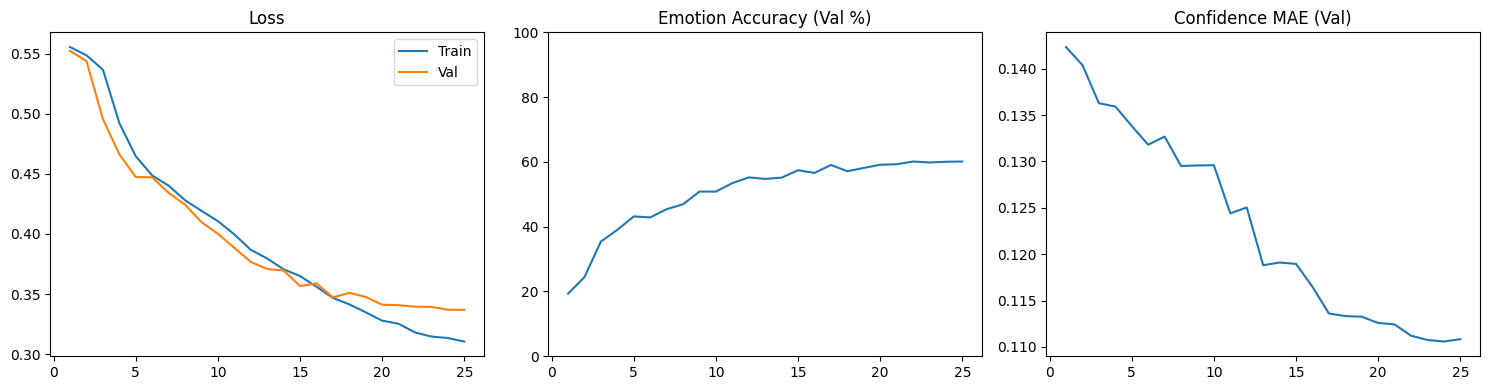

Best Val Loss: 0.3369
Final Emotion Acc: 60.1%
Best Confidence MAE: 0.1106


In [13]:
# ============================================================
# CELL 10: Plot training history
# ============================================================
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['val_acc'] * 100)
axes[1].set_title('Emotion Accuracy (Val %)')
axes[1].set_ylim(0, 100)

axes[2].plot(hist_df['epoch'], hist_df['val_mae'])
axes[2].set_title('Confidence MAE (Val)')

plt.tight_layout()
plt.savefig(str(SAVE_PATH.parent / 'training_history.png'), dpi=120)
plt.show()
print(f'Best Val Loss: {best_val_loss:.4f}')
print(f'Final Emotion Acc: {hist_df["val_acc"].max()*100:.1f}%')
print(f'Best Confidence MAE: {hist_df["val_mae"].min():.4f}')

In [18]:
# ============================================================
# CELL 11: Download model (Colab) or confirm path (Local)
# ============================================================
print(f'✅ Model saved to: {SAVE_PATH.resolve()}')

if not LOCAL_MODE:
    try:
        from google.colab import files
        files.download(str(SAVE_PATH))
        print('Downloading... move best_model.pth to your api/ folder.')
    except Exception as e:
        print(f'Auto-download failed: {e}')
        print('Manually download via Files sidebar → right-click → Download')
else:
    print('Local mode: copy best_model.pth to your api/ folder.')
    print(f'Path: {SAVE_PATH.resolve()}')

✅ Model saved to: /content/best_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading... move best_model.pth to your api/ folder.
